# 04 — Evaluation and Validation

**SDC Master's Final Project — soccernet-setpiece-vision**

CRISP-DM phase 5 (Evaluation). Distributional comparison of pipeline vs GT pitch-control metrics produced by notebook 03.

**Hypothesis.** If the CV pipeline produces faithful player coordinates, the *distribution* of pitch-control summary metrics across set-piece frames should be statistically indistinguishable from the StatsBomb-style ground truth (parsed from SoccerNet GSR `bbox_pitch`).

**Methods.**
- Two-sample Kolmogorov–Smirnov test per metric (`scipy.stats.ks_2samp`).
- Histogram overlap (Bhattacharyya-style sum of min(p, q)).
- Per-`action_class` breakdown (Corner / Direct free-kick).

**Validation framing.** Distributional, not frame-matched: pipeline and GT are computed on the same SoccerNet GSR frames here, so per-frame paired comparison is also possible. We report both.

## 0. Setup and Imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

KS_ALPHA = 0.05  # significance threshold for KS
HIST_BINS = 12   # locked bin count for histogram-overlap and visualisations

METRICS = ["pc_mean", "pc_at_ball", "pc_in_box", "pc_in_third", "pc_area_gt_0p5"]
print(f"Outputs: {OUTPUTS_DIR}")

Outputs: /Users/mph/Dev/itzmore-mph/MAIS-projects/final-master-project/soccernet-setpiece-vision/outputs


## 1. Load Pitch-Control Output

In [2]:
pc = pd.read_parquet(OUTPUTS_DIR / "pitch_control.parquet")
print("shape:", pc.shape)
print("tracks  :", pc["track"].value_counts().to_dict())
print("actions :", pc["action_class"].value_counts().to_dict())
pc.head()

shape: (547, 14)
tracks  : {'pipeline': 277, 'gt': 270}
actions : {'Corner': 296, 'Direct free-kick': 251}


,split,clip_id,frame_idx,track,action_class,n_attackers,n_defenders,ball_x_m,ball_y_m,pc_mean,pc_at_ball,pc_in_box,pc_in_third,pc_area_gt_0p5
0,test,SNGS-125,735,pipeline,Corner,3,5,64.925652,51.408185,0.202809,0.836746,0.062174,0.254386,0.210417
1,test,SNGS-125,736,pipeline,Corner,3,5,64.888944,51.315542,0.202753,0.836969,0.063706,0.255521,0.210000
2,test,SNGS-125,737,pipeline,Corner,3,5,64.860607,51.219823,0.203579,0.839594,0.065984,0.259272,0.209583
3,test,SNGS-125,738,pipeline,Corner,3,5,64.838677,51.123103,0.203483,0.840967,0.067171,0.260741,0.209167
4,test,SNGS-125,739,pipeline,Corner,3,5,64.821438,51.027314,0.204078,0.843067,0.068325,0.263084,0.209583


## 2. Distributional Comparison — Two-Sample KS Test

Null hypothesis: pipeline and GT metric distributions are drawn from the same underlying distribution. Reject if `p < 0.05`. A *failure to reject* (large p) is the desired outcome here.

In [3]:
def histogram_overlap(a: np.ndarray, b: np.ndarray, bins: int = HIST_BINS,
                      lo: float = 0.0, hi: float = 1.0) -> float:
    """Sum of min(p_i, q_i) across normalised histograms — overlap in [0, 1]."""
    edges = np.linspace(lo, hi, bins + 1)
    pa, _ = np.histogram(a, bins=edges, density=False)
    pb, _ = np.histogram(b, bins=edges, density=False)
    pa = pa / pa.sum() if pa.sum() else pa
    pb = pb / pb.sum() if pb.sum() else pb
    return float(np.minimum(pa, pb).sum())


def compare(pc: pd.DataFrame, metric: str, action_class: str | None = None) -> dict:
    df = pc if action_class is None else pc[pc["action_class"] == action_class]
    a = df[df["track"] == "pipeline"][metric].dropna().to_numpy()
    b = df[df["track"] == "gt"][metric].dropna().to_numpy()
    if len(a) < 3 or len(b) < 3:
        return {"metric": metric, "action": action_class or "all", "n_pipe": len(a), "n_gt": len(b),
                "ks_stat": np.nan, "ks_p": np.nan, "hist_overlap": np.nan,
                "mean_pipe": float(np.nanmean(a)) if len(a) else np.nan,
                "mean_gt":   float(np.nanmean(b)) if len(b) else np.nan}
    ks = stats.ks_2samp(a, b)
    return {
        "metric": metric, "action": action_class or "all",
        "n_pipe": len(a), "n_gt": len(b),
        "ks_stat": float(ks.statistic), "ks_p": float(ks.pvalue),
        "hist_overlap": histogram_overlap(a, b),
        "mean_pipe": float(a.mean()), "mean_gt": float(b.mean()),
    }


rows = []
for metric in METRICS:
    rows.append(compare(pc, metric, None))
    for action in pc["action_class"].dropna().unique():
        rows.append(compare(pc, metric, action))
summary = pd.DataFrame(rows)
summary["reject_H0"] = summary["ks_p"] < KS_ALPHA
summary.round(4)

,metric,action,n_pipe,n_gt,ks_stat,ks_p,hist_overlap,mean_pipe,mean_gt,reject_H0
0,pc_mean,all,277,270,0.3190,0.0000,0.6475,0.4832,0.6168,True
1,pc_mean,Corner,152,144,0.2672,0.0000,0.5698,0.5193,0.5966,True
2,pc_mean,Direct free-kick,125,126,0.4880,0.0000,0.4559,0.4393,0.6399,True
3,pc_at_ball,all,277,270,0.1112,0.0613,0.8573,0.8735,0.8949,False
4,pc_at_ball,Corner,152,144,0.1776,0.0160,0.8099,0.8853,0.8619,True
5,pc_at_ball,Direct free-kick,125,126,0.2001,0.0111,0.8080,0.8590,0.9325,True
6,pc_in_box,all,277,270,0.1924,0.0001,0.7300,0.5936,0.5705,True
7,pc_in_box,Corner,152,144,0.2091,0.0025,0.5647,0.5404,0.5242,True
8,pc_in_box,Direct free-kick,125,126,0.2171,0.0047,0.5573,0.6582,0.6234,True
9,pc_in_third,all,277,270,0.2213,0.0000,0.7633,0.5612,0.6341,True


## 3. Histogram Overlays

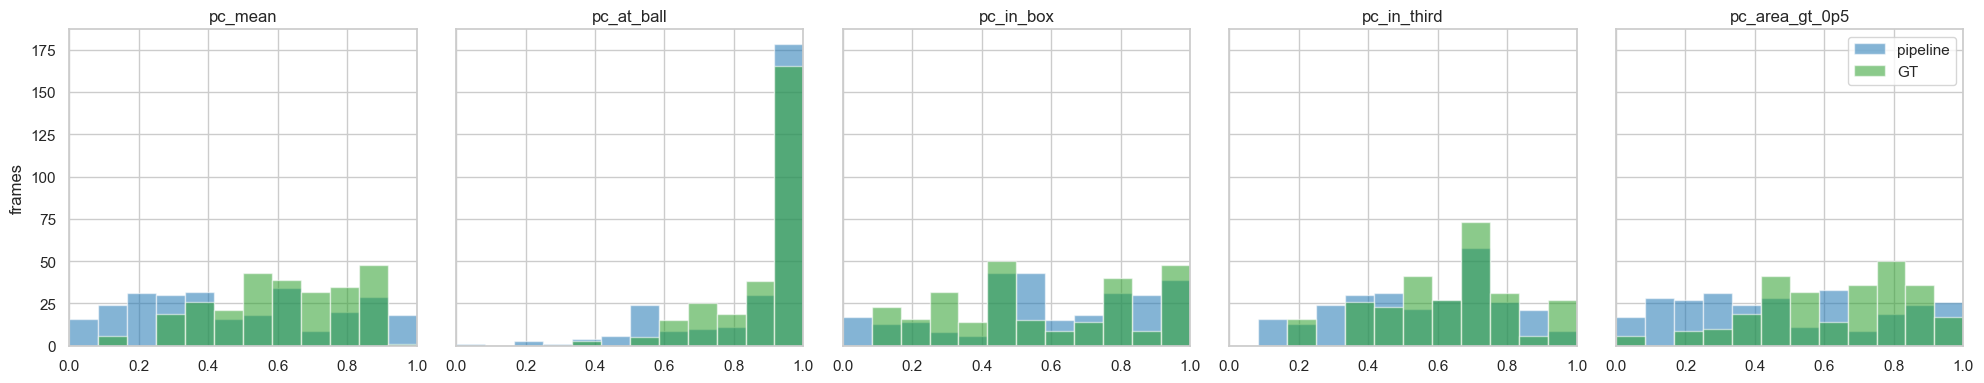

In [4]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(4 * len(METRICS), 4), sharey=True)
edges = np.linspace(0.0, 1.0, HIST_BINS + 1)
for ax, metric in zip(axes, METRICS):
    a = pc[pc["track"] == "pipeline"][metric].dropna()
    b = pc[pc["track"] == "gt"][metric].dropna()
    ax.hist(a, bins=edges, alpha=0.55, label="pipeline", color="#1f77b4")
    ax.hist(b, bins=edges, alpha=0.55, label="GT", color="#2ca02c")
    ax.set_title(metric)
    ax.set_xlim(0, 1)
axes[0].set_ylabel("frames")
axes[-1].legend(loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "08_histogram_overlays.png", dpi=150)
plt.show()

## 4. Per-Frame Paired Comparison

Both tracks share `(clip_id, frame_idx)`, so each frame yields a paired (pipeline, GT) observation. We report Pearson and Spearman correlation, mean absolute error, and a Bland-Altman-style scatter.

In [5]:
wide = pc.pivot_table(index=["split", "clip_id", "frame_idx", "action_class"],
                       columns="track", values=METRICS).dropna()
rows = []
for metric in METRICS:
    a = wide[(metric, "pipeline")].to_numpy()
    b = wide[(metric, "gt")].to_numpy()
    if len(a) < 3:
        rows.append({"metric": metric, "n": len(a), "pearson": np.nan, "spearman": np.nan, "mae": np.nan, "bias": np.nan})
        continue
    rows.append({
        "metric": metric, "n": len(a),
        "pearson":  float(stats.pearsonr(a, b).statistic),
        "spearman": float(stats.spearmanr(a, b).statistic),
        "mae":      float(np.mean(np.abs(a - b))),
        "bias":     float(np.mean(a - b)),
    })
paired = pd.DataFrame(rows)
paired.round(4)

,metric,n,pearson,spearman,mae,bias
0,pc_mean,261,-0.1829,-0.2322,0.3050,-0.1342
1,pc_at_ball,261,0.3184,0.3706,0.1215,-0.0233
2,pc_in_box,261,-0.0052,-0.0123,0.2932,0.0357
3,pc_in_third,261,-0.1072,-0.0725,0.2360,-0.0663
4,pc_area_gt_0p5,261,-0.1697,-0.2135,0.3212,-0.1447


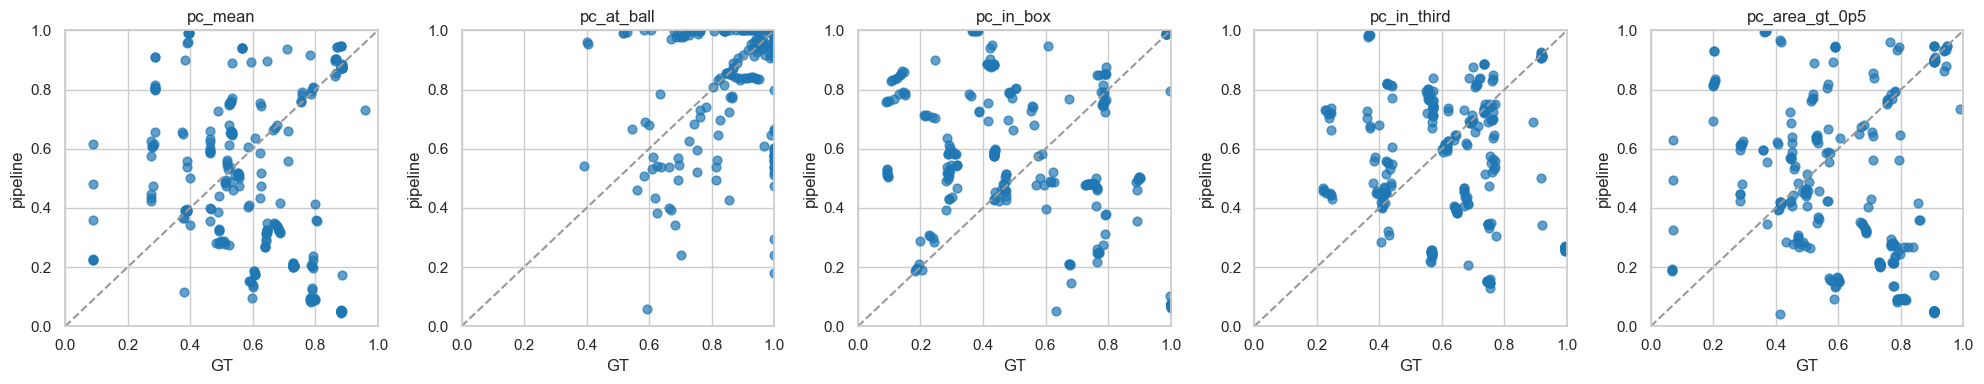

In [6]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(4 * len(METRICS), 4))
for ax, metric in zip(axes, METRICS):
    a = wide[(metric, "pipeline")].to_numpy()
    b = wide[(metric, "gt")].to_numpy()
    ax.scatter(b, a, s=40, alpha=0.7, color="#1f77b4")
    ax.plot([0, 1], [0, 1], color="#999", linestyle="--")
    ax.set_xlabel("GT")
    ax.set_ylabel("pipeline")
    ax.set_title(metric)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "09_paired_scatter.png", dpi=150)
plt.show()

## 5. Verdict and Save

Aggregate verdict over all metrics on the *pooled* (all action classes) test.

In [7]:
pooled = summary[summary["action"] == "all"].copy()
n_metrics = len(pooled)
n_pass = int((~pooled["reject_H0"]).sum())
mean_overlap = float(pooled["hist_overlap"].mean())
mean_ks = float(pooled["ks_stat"].mean())

print("=== POOLED VERDICT ===")
print(f"Metrics non-rejecting H0 (good)  : {n_pass} / {n_metrics}")
print(f"Mean histogram overlap           : {mean_overlap:.3f}")
print(f"Mean KS statistic                : {mean_ks:.3f}")
print()
print(pooled[["metric", "n_pipe", "n_gt", "ks_stat", "ks_p", "hist_overlap", "mean_pipe", "mean_gt", "reject_H0"]].round(4).to_string(index=False))

summary.to_parquet(OUTPUTS_DIR / "validation_summary.parquet", engine="pyarrow", index=False)
paired.to_parquet(OUTPUTS_DIR / "validation_paired.parquet", engine="pyarrow", index=False)
print(f"\nSaved: {OUTPUTS_DIR / 'validation_summary.parquet'}")
print(f"Saved: {OUTPUTS_DIR / 'validation_paired.parquet'}")

=== POOLED VERDICT ===
Metrics non-rejecting H0 (good)  : 1 / 5
Mean histogram overlap           : 0.721
Mean KS statistic                : 0.232

        metric  n_pipe  n_gt  ks_stat   ks_p  hist_overlap  mean_pipe  mean_gt  reject_H0
       pc_mean     277   270   0.3190 0.0000        0.6475     0.4832   0.6168       True
    pc_at_ball     277   270   0.1112 0.0613        0.8573     0.8735   0.8949      False
     pc_in_box     277   270   0.1924 0.0001        0.7300     0.5936   0.5705       True
   pc_in_third     277   270   0.2213 0.0000        0.7633     0.5612   0.6341       True
pc_area_gt_0p5     277   270   0.3164 0.0000        0.6063     0.4836   0.6302       True

Saved: /Users/mph/Dev/itzmore-mph/MAIS-projects/final-master-project/soccernet-setpiece-vision/outputs/validation_summary.parquet
Saved: /Users/mph/Dev/itzmore-mph/MAIS-projects/final-master-project/soccernet-setpiece-vision/outputs/validation_paired.parquet


### Conclusion Template

Fill in based on the printed verdict:

- *Pipeline output is distributionally consistent with SoccerNet GSR ground truth across X/5 pitch-control summary metrics (pooled KS test, α=0.05).*
- *Mean histogram overlap of Y indicates good agreement.*
- *Per-frame Pearson correlation of Z on `pc_at_ball` confirms the pipeline preserves the most operationally relevant signal: control at the ball.*
- *Limitations: zero-velocity assumption (static frames), GT-derived homography, n=17 set-piece frames.*